### Modèles de regressions avec de la régularisation

In [74]:
import sys
sys.path.append('..')

from utils.fonctions import load_parquet_data, load_pickle

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import numpy as np
import sklearn

sklearn.set_config(transform_output='pandas')
import matplotlib.pyplot as plt

In [27]:
df = load_parquet_data("../ressources/data/3_cleaned/enedis_ban_ademe_extract_PARIS_2022_entrop_numerized.parquet")
df.head()

Loading parquet data from : ../ressources/data/3_cleaned/enedis_ban_ademe_extract_PARIS_2022_entrop_numerized.parquet..


,qualite_isolation_menuiseries_ademe,qualite_isolation_murs_ademe,qualite_isolation_plancher_haut_comble_perdu_ademe,qualite_isolation_enveloppe_ademe,qualite_isolation_plancher_bas_ademe,qualite_isolation_plancher_haut_toit_terrase_ademe,indicateur_confort_ete_ademe,logement_traversant_0_1_ademe,presence_brasseur_air_0_1_ademe,protection_solaire_exterieure_0_1_ademe,...,conso_chauffage_depensier_e_primaire_ademe,score_ban_ademe,surface_habitable_immeuble_ademe,annee_construction_ademe,nombre_niveau_immeuble_ademe,consommation_annuelle_totale_de_l_adresse_mwh_enedis_with_ban,consommation_annuelle_moyenne_de_la_commune_mwh_enedis_with_ban,lon_enedis_with_ban,lat_enedis_with_ban,consommation_annuelle_moyenne_par_logement_de_l_adresse_kwh_enedis_with_ban
0,4,1.0,4.0,1,4.0,-1.0,-1.0,1.0,0.0,1.0,...,20573.599609,0.72,2587.0,1947.0,7.0,78.292,2.686,2.328325,48.84874,4350.0
1,1,1.0,1.0,4,4.0,-1.0,-1.0,0.0,0.0,0.0,...,2312.300049,0.72,2587.0,1947.0,7.0,78.292,2.686,2.328325,48.84874,4350.0
2,1,1.0,4.0,1,4.0,-1.0,-1.0,1.0,0.0,0.0,...,41476.398438,0.72,2587.0,1947.0,7.0,78.292,2.686,2.328325,48.84874,4350.0
3,2,1.0,1.0,3,4.0,-1.0,-1.0,0.0,0.0,0.0,...,4481.700195,0.72,2587.0,1947.0,7.0,78.292,2.686,2.328325,48.84874,4350.0
4,3,1.0,3.0,4,4.0,-1.0,-1.0,1.0,0.0,0.0,...,4594.100098,0.72,2587.0,1947.0,7.0,78.292,2.686,2.328325,48.84874,4350.0


In [23]:
assert 'consommation_annuelle_moyenne_par_logement_de_l_adresse_kwh_enedis_with_ban' in df
TARGET_COL = 'consommation_annuelle_moyenne_par_logement_de_l_adresse_kwh_enedis_with_ban'

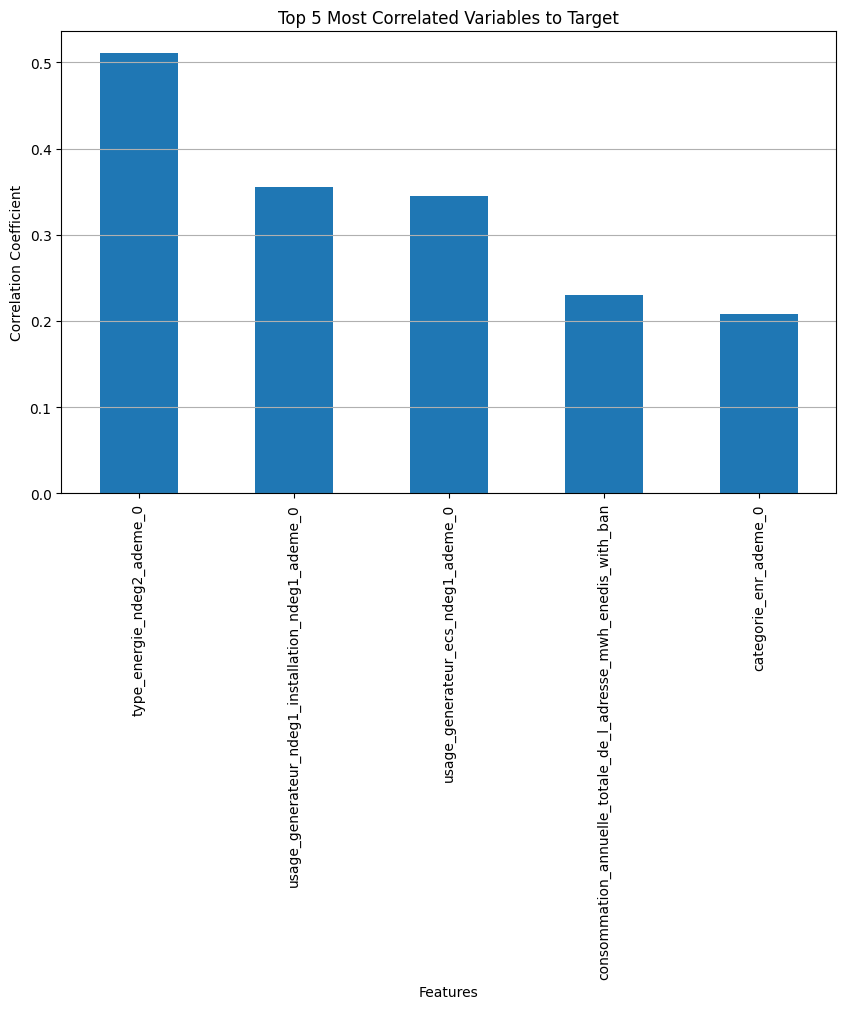

In [ ]:
# correlations with the target column
correlations = df.corr()[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)

# top 5 most correlated variables
top_5_features = correlations.head(5)

top_5_features.plot(kind='bar', title='Top 5 Most Correlated Variables to Target', figsize=(10, 6))
plt.ylabel('Correlation Coefficient')
plt.xlabel('Features')
plt.grid(axis='y')
plt.show()

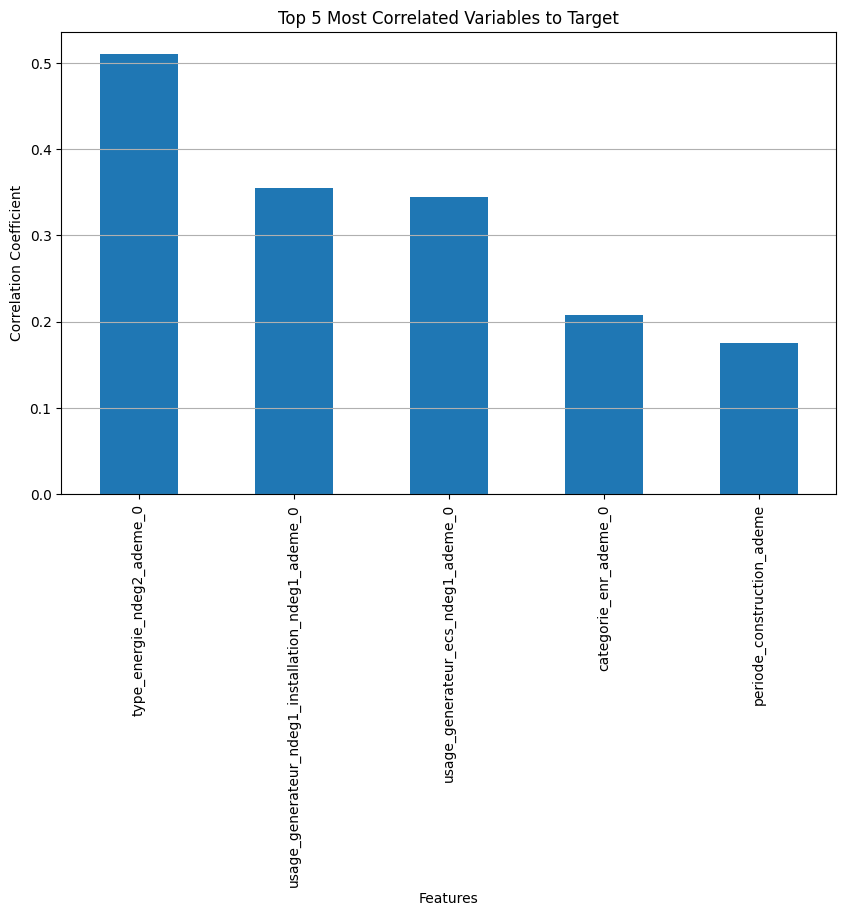

In [29]:
df = df.drop(columns=['consommation_annuelle_totale_de_l_adresse_mwh_enedis_with_ban'])

# Calculate correlations with the target column
correlations = df.corr()[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)

# Select the top 5 most correlated variables
top_5_features = correlations.head(5)

# Plot the correlations
top_5_features.plot(kind='bar', title='Top 5 Most Correlated Variables to Target', figsize=(10, 6))
plt.ylabel('Correlation Coefficient')
plt.xlabel('Features')
plt.grid(axis='y')
plt.show()

In [31]:
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [96]:
categ_encoders = load_pickle('../ressources/encoders_fitted/categorical_encoders.pkl')
cols_to_scale = set(X_train.columns)

# cols_to_scale -= set(categ_encoders['label_encoding'].get_feature_names())
# cols_to_scale -= set(categ_encoders['ordinal_encoding'].get_feature_names())
cols_to_scale = list(cols_to_scale)

def model_pipeline(model=None, cols_to_scale=cols_to_scale):
    # scaling
    return Pipeline([
        ('scaling', ColumnTransformer([('s_scaler', StandardScaler(), cols_to_scale)], remainder='passthrough', verbose_feature_names_out=False)),
        ('model', model)
    ])

### Lasso and Ridge Regressions

Lasso (Least Absolute Shrinkage and Selection Operator) and Ridge regression are regularization techniques used to prevent overfitting in linear regression models by adding a penalty term to the loss function.

#### The Alpha Parameter
- The **alpha** parameter controls the strength of the regularization:
    - A higher alpha increases the penalty, leading to more shrinkage of coefficients.
    - A lower alpha reduces the penalty, making the model closer to standard linear regression.
- Choosing the right alpha is crucial and is often done using cross-validation.

In [103]:
# grid for Ridge
ridge_param_grid = {'alpha': np.linspace(0.001, 5, 20)}
ridge_random_search = RandomizedSearchCV(Ridge(), ridge_param_grid, n_iter=5, cv=2, scoring='r2', random_state=23)

# grid for Lasso
lasso_param_grid = {'alpha': np.logspace(0.001, 10, 20)}
lasso_random_search = RandomizedSearchCV(Lasso(), lasso_param_grid, n_iter=5, cv=2, scoring='r2', random_state=23)

def evaluate_model(model, X_train, X_test, y_train, y_test):
    # fonction pour calculer les métriques
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return round(rmse, 3), round(mape, 3), round(r2, 3)

# évaluer des modèles
ridge_metrics = evaluate_model(Ridge(alpha=5), X_train, X_test, y_train, y_test)
lasso_metrics = evaluate_model(Lasso(alpha=5), X_train, X_test, y_train, y_test)

print("Ridge - RMSE:", ridge_metrics[0], "MAPE:", ridge_metrics[1], "R2:", ridge_metrics[2])
# print("Lasso - RMSE:", lasso_metrics[0], "MAPE:", lasso_metrics[1], "R2:", lasso_metrics[2])

Ridge - RMSE: 989.871 MAPE: 0.294 R2: 0.415


In [35]:
import warnings
warnings.filterwarnings('ignore')

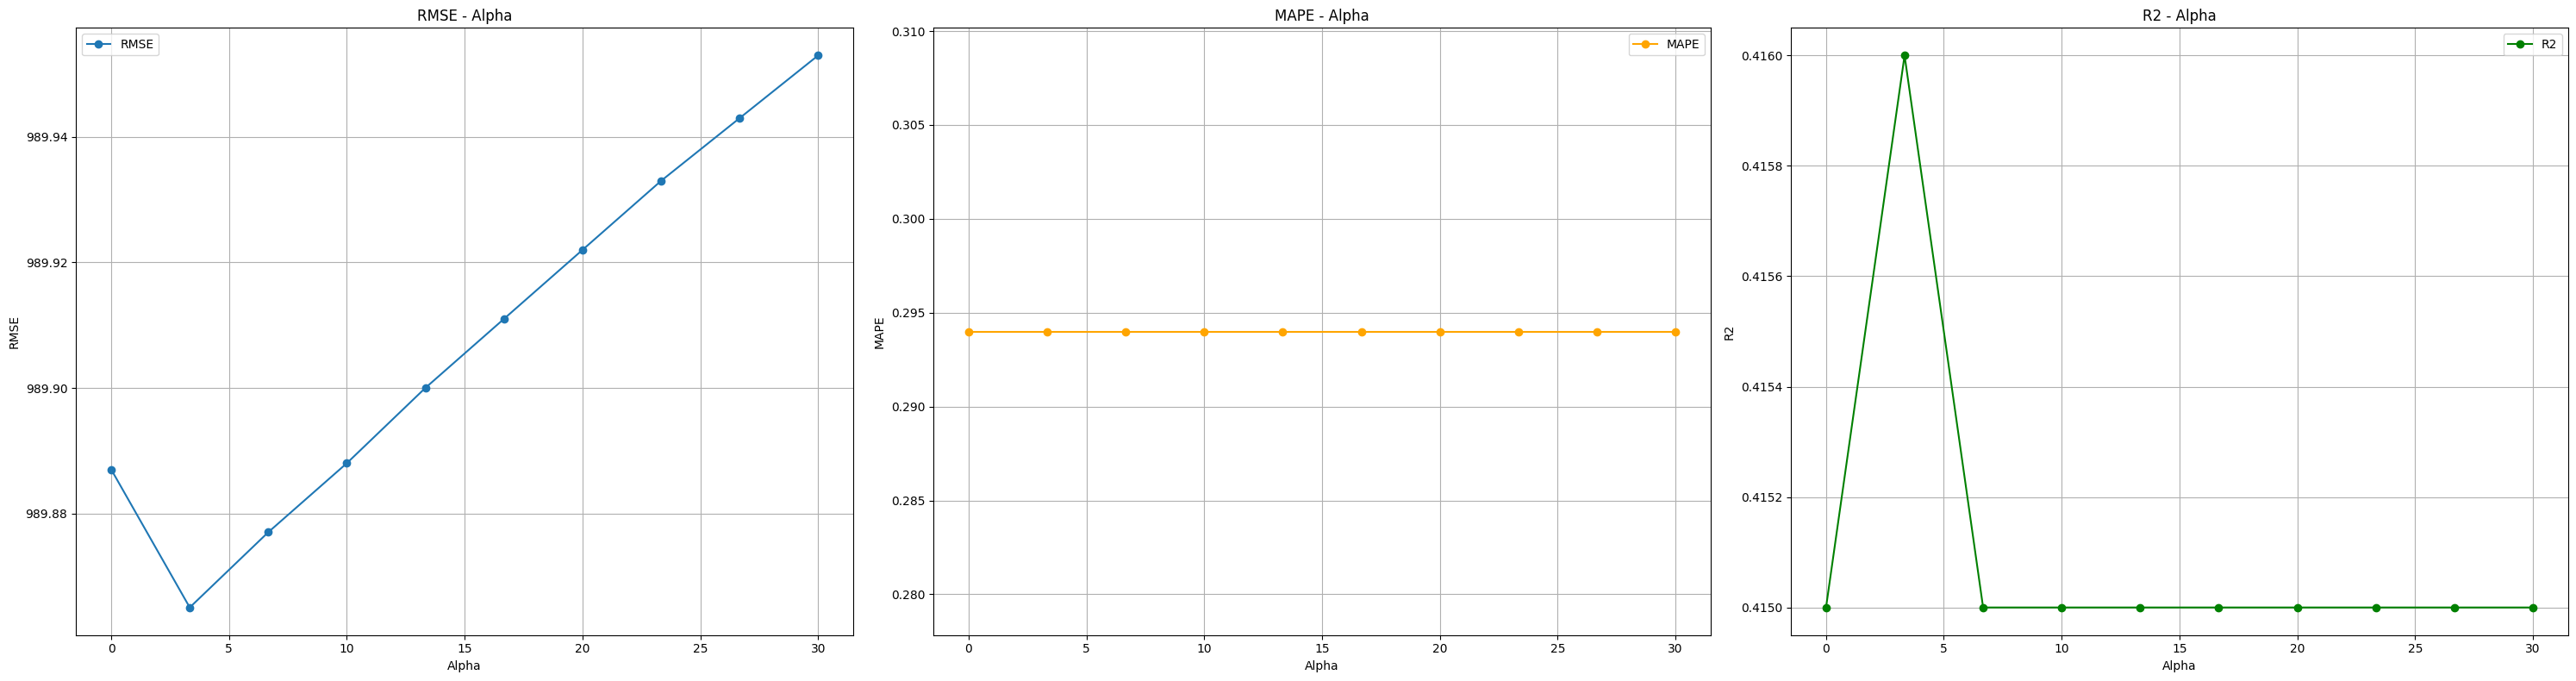

In [101]:
alphas = np.linspace(0, 30, 10)
rmse_scores = []
mape_scores = []
r2_scores = []

for alpha in alphas:
    ridge = model_pipeline(model = Ridge(alpha=alpha))
    ridge.fit(X_train, y_train)
    y_pred = ridge.predict(X_test)
    rmse_scores.append(round(np.sqrt(mean_squared_error(y_test, y_pred)), 3))
    mape_scores.append(round(mean_absolute_percentage_error(y_test, y_pred), 3))
    r2_scores.append(round(r2_score(y_test, y_pred), 3))

# Plotting the scores
fig, axes = plt.subplots(1, 3, figsize=(30, 8))

axes[0].plot(alphas, rmse_scores, marker='o', label='RMSE')
axes[0].set_title('RMSE - Alpha')
axes[0].set_xlabel('Alpha')
axes[0].set_ylabel('RMSE')
axes[0].grid()
axes[0].legend()

axes[1].plot(alphas, mape_scores, marker='o', label='MAPE', color='orange')
axes[1].set_title('MAPE - Alpha')
axes[1].set_xlabel('Alpha')
axes[1].set_ylabel('MAPE')
axes[1].grid()
axes[1].legend()

axes[2].plot(alphas, r2_scores, marker='o', label='R2', color='green')
axes[2].set_title('R2 - Alpha')
axes[2].set_xlabel('Alpha')
axes[2].set_ylabel('R2')
axes[2].grid()
axes[2].legend()

plt.tight_layout()
plt.show()

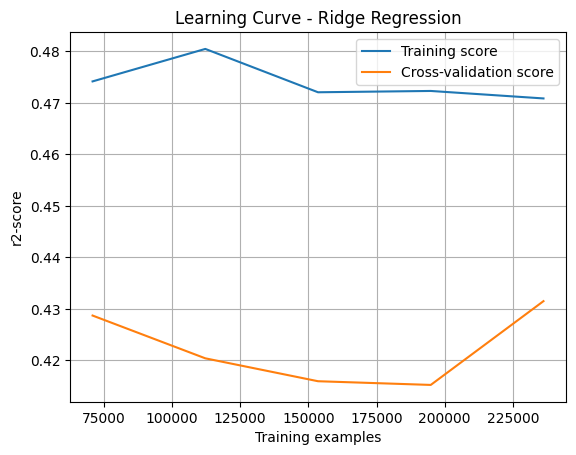

In [100]:
# fonction pour tracer les courbes d'apprentissage
def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, test_scores = learning_curve(model, X, y, cv=5, scoring='r2', train_sizes=np.linspace(0.3, 1, 5), n_jobs=-1)
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    plt.figure()
    plt.plot(train_sizes, train_scores_mean, label="Training score")
    plt.plot(train_sizes, test_scores_mean, label="Cross-validation score")
    plt.title(title)
    plt.xlabel("Training examples")
    plt.ylabel("r2-score")
    plt.legend()
    plt.grid()
    plt.show()

# tracer les courbes d'apprentissage
plot_learning_curve(model_pipeline(Ridge()), X_train, y_train, "Learning Curve - Ridge Regression")

In [84]:
import pandas as pd

type_energie_principale_chauffage_ademe_0           2.039731e+14
periode_construction_ademe                          1.336806e+03
hauteur_sous_plafond_ademe                          8.119952e+02
presence_brasseur_air_0_1_ademe                     4.945080e+02
annee_construction_ademe                            4.712791e+02
                                                        ...     
configuration_installation_ecs_ademe_0             -3.754725e+02
conso_5_usages_par_m2_e_primaire_ademe             -5.210372e+02
type_generateur_ndeg1_installation_ndeg1_ademe_0   -6.731941e+02
deperditions_planchers_bas_ademe                   -1.354198e+03
deperditions_baies_vitrees_ademe                   -3.051288e+15
Length: 87, dtype: float64


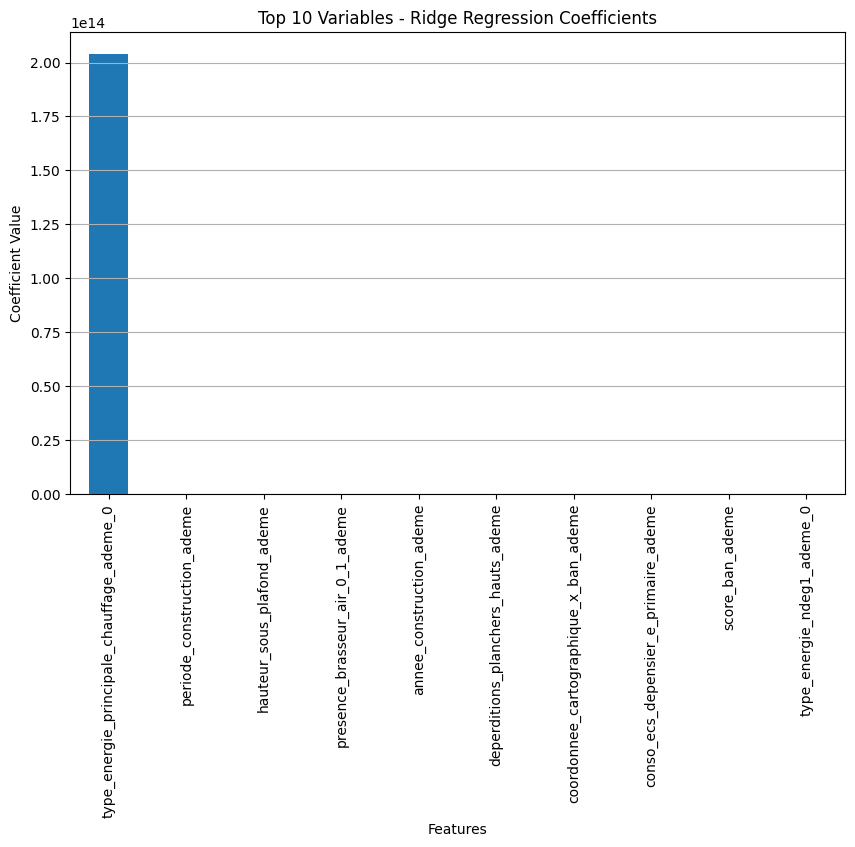

In [102]:
# Entraîner le modèle Ridge avec l'alpha sélectionné
ridge_model = model_pipeline(Ridge(alpha=0))
ridge_model.fit(X_train, y_train)

# Extraire les coefficients des variables
ridge_coefficients = pd.Series(ridge_model['model'].coef_, index=X_train.columns)

# Trier les coefficients par ordre décroissant pour voir les plus importants
ridge_coefficients_sorted = ridge_coefficients.sort_values(ascending=False)

# Afficher les coefficients
print(ridge_coefficients_sorted)

# Visualiser les coefficients les plus importants
ridge_coefficients_sorted.head(10).plot(kind='bar', title='Top 10 Variables - Ridge Regression Coefficients', figsize=(10, 6))
plt.ylabel('Coefficient Value')
plt.xlabel('Features')
plt.grid(axis='y')
plt.show()

In [89]:
X_train['besoin_refroidissement_ademe'].value_counts()

besoin_refroidissement_ademe
0.000000        291905
24843.900391        22
2457.100098          7
155.800003           4
77.300003            4
                 ...  
422.500000           1
349.500000           1
988.000000           1
2254.100098          1
263.399994           1
Name: count, Length: 2822, dtype: int64

In [91]:
X_train['hauteur_sous_plafond_ademe'].value_counts()

hauteur_sous_plafond_ademe
2.500000      142816
2.600000       46598
2.700000       40240
2.800000       26809
2.900000        9594
               ...  
12.500000          1
259.000000         1
263.000000         1
221.699997         1
8.800000           1
Name: count, Length: 103, dtype: int64